In [1]:
#CELL 1 - Setup
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Research/glycemic-hybrid-ga

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

colors = {
    "GA-only": "blue",
    "GA+Rules": "red",
    "GA+Surrogate": "orange",
    "Hybrid": "green",
}

method_names = {
    "ga_only": "GA-only",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "GA+Surrogate",
    "hybrid": "Hybrid",
}

method_order = ["GA-only", "GA+Rules", "GA+Surrogate", "Hybrid"]

Mounted at /content/drive
/content/drive/MyDrive/Research/glycemic-hybrid-ga


In [2]:
#CELL 2 - Load results
summary_path = "outputs/results/summary_all.csv"

df = pd.read_csv(summary_path)
df["MethodLabel"] = df["Method"].map(method_names)

df["MethodLabel"] = pd.Categorical(
    df["MethodLabel"],
    categories=method_order,
    ordered=True
)

df = df.sort_values(["Scenario", "MethodLabel"])
df

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,SevereHypo,SimCalls,DatasetSize,AUCsum,AUCmean,AUCregret,MethodLabel
0,S1_normal,ga_only,99.374014,99.374014,100.000000,0.0,0.000000,92.877338,135.875743,110.822083,0,2400,-1,5954.712182,99.245203,9.581747,GA-only
1,S1_normal,ga_rules,99.178881,99.178881,100.000000,0.0,0.000000,79.786971,139.775824,109.860057,0,2400,-1,5948.500595,99.141677,15.793334,GA+Rules
2,S1_normal,ga_surrogate,99.404899,99.404899,100.000000,0.0,0.000000,88.296957,133.896006,110.213543,0,1752,1752,5952.006190,99.200103,12.287739,GA+Surrogate
3,S1_normal,hybrid,99.222139,99.222139,100.000000,0.0,0.000000,80.164327,125.770374,107.744512,0,1752,1752,5952.268221,99.204470,12.025708,Hybrid
4,S2_ramadan,ga_only,98.904381,98.904381,100.000000,0.0,0.000000,71.724759,159.434062,108.942920,0,2400,-1,5926.712623,98.778544,13.568054,GA-only
5,S2_ramadan,ga_rules,98.987936,98.987936,100.000000,0.0,0.000000,78.757416,165.565792,110.463753,0,2400,-1,5933.711249,98.895187,6.569429,GA+Rules
6,S2_ramadan,ga_surrogate,98.939039,98.939039,100.000000,0.0,0.000000,86.148628,140.131364,114.400953,0,1752,1752,5936.342366,98.939039,3.938312,GA+Surrogate
7,S2_ramadan,hybrid,99.004678,99.004678,100.000000,0.0,0.000000,77.622338,149.973937,110.375584,0,1752,1752,5924.634781,98.743913,15.645896,Hybrid
8,S3_stress_highcarb,ga_only,98.221204,98.221204,100.000000,0.0,0.000000,74.033752,152.682695,117.110293,0,2400,-1,5721.150903,95.352515,201.736015,GA-only
9,S3_stress_highcarb,ga_rules,98.714782,98.714782,100.000000,0.0,0.000000,71.230041,143.352138,108.135026,0,2400,-1,5509.498811,91.824980,413.388107,GA+Rules


In [3]:
#CELL 3 - Basic ablation table
ablation_cols = [
    "Scenario",
    "MethodLabel",
    "Fitness",
    "BestTrueFitness",
    "TIR",
    "TBR",
    "TAR",
    "Gmin",
    "Gmax",
    "MeanG",
    "AUCmean",
    "AUCregret",
    "SimCalls"
]

ablation = df[ablation_cols].copy()
ablation

,Scenario,MethodLabel,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,AUCmean,AUCregret,SimCalls
0,S1_normal,GA-only,99.374014,99.374014,100.000000,0.0,0.000000,92.877338,135.875743,110.822083,99.245203,9.581747,2400
1,S1_normal,GA+Rules,99.178881,99.178881,100.000000,0.0,0.000000,79.786971,139.775824,109.860057,99.141677,15.793334,2400
2,S1_normal,GA+Surrogate,99.404899,99.404899,100.000000,0.0,0.000000,88.296957,133.896006,110.213543,99.200103,12.287739,1752
3,S1_normal,Hybrid,99.222139,99.222139,100.000000,0.0,0.000000,80.164327,125.770374,107.744512,99.204470,12.025708,1752
4,S2_ramadan,GA-only,98.904381,98.904381,100.000000,0.0,0.000000,71.724759,159.434062,108.942920,98.778544,13.568054,2400
5,S2_ramadan,GA+Rules,98.987936,98.987936,100.000000,0.0,0.000000,78.757416,165.565792,110.463753,98.895187,6.569429,2400
6,S2_ramadan,GA+Surrogate,98.939039,98.939039,100.000000,0.0,0.000000,86.148628,140.131364,114.400953,98.939039,3.938312,1752
7,S2_ramadan,Hybrid,99.004678,99.004678,100.000000,0.0,0.000000,77.622338,149.973937,110.375584,98.743913,15.645896,1752
8,S3_stress_highcarb,GA-only,98.221204,98.221204,100.000000,0.0,0.000000,74.033752,152.682695,117.110293,95.352515,201.736015,2400
9,S3_stress_highcarb,GA+Rules,98.714782,98.714782,100.000000,0.0,0.000000,71.230041,143.352138,108.135026,91.824980,413.388107,2400


In [4]:
#CELL 4 - Component interpretation table
component_map = {
    "GA-only": "Evolutionary search only",
    "GA+Rules": "Evolutionary search + rule-based safety",
    "GA+Surrogate": "Evolutionary search + surrogate learning",
    "Hybrid": "Evolutionary search + surrogate learning + safety-aware selective simulation"
}

ablation["ComponentSetting"] = ablation["MethodLabel"].astype(str).map(component_map)
ablation[["MethodLabel", "ComponentSetting"]].drop_duplicates()

,MethodLabel,ComponentSetting
0,GA-only,Evolutionary search only
1,GA+Rules,Evolutionary search + rule-based safety
2,GA+Surrogate,Evolutionary search + surrogate learning
3,Hybrid,Evolutionary search + surrogate learning + saf...


In [5]:
#CELL 5 - Average performance across scenarios
avg_perf = df.groupby("MethodLabel", observed=True).agg(
    Fitness_mean=("Fitness", "mean"),
    TIR_mean=("TIR", "mean"),
    TAR_mean=("TAR", "mean"),
    TBR_mean=("TBR", "mean"),
    AUCregret_mean=("AUCregret", "mean"),
    SimCalls_mean=("SimCalls", "mean"),
).reset_index()

avg_perf

,MethodLabel,Fitness_mean,TIR_mean,TAR_mean,TBR_mean,AUCregret_mean,SimCalls_mean
0,GA-only,98.525670,100.000000,0.000000,0.0,165.917354,2400.0
1,GA+Rules,98.638046,100.000000,0.000000,0.0,116.570726,2400.0
2,GA+Surrogate,98.414700,100.000000,0.000000,0.0,132.813361,1752.0
3,Hybrid,98.092248,99.913495,0.086505,0.0,94.809923,1752.0


In [6]:
#CELL 6 - Simulation reduction
ga_cost = df[df["Method"] == "ga_only"]["SimCalls"].mean()

avg_perf["Reduction_vs_GA_percent"] = (
    (ga_cost - avg_perf["SimCalls_mean"]) / ga_cost * 100.0
)

avg_perf

,MethodLabel,Fitness_mean,TIR_mean,TAR_mean,TBR_mean,AUCregret_mean,SimCalls_mean,Reduction_vs_GA_percent
0,GA-only,98.525670,100.000000,0.000000,0.0,165.917354,2400.0,0.0
1,GA+Rules,98.638046,100.000000,0.000000,0.0,116.570726,2400.0,0.0
2,GA+Surrogate,98.414700,100.000000,0.000000,0.0,132.813361,1752.0,27.0
3,Hybrid,98.092248,99.913495,0.086505,0.0,94.809923,1752.0,27.0


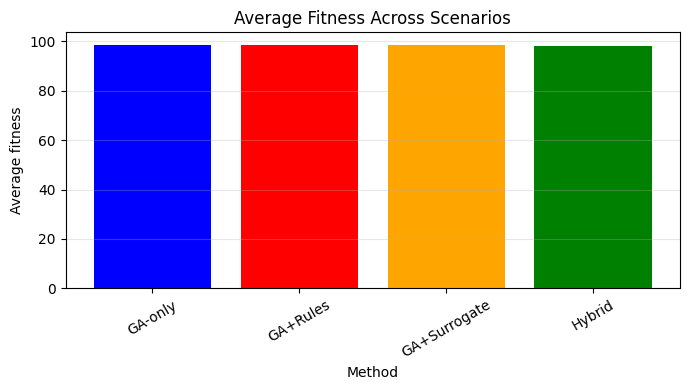

Saved: figures/ablation_average_fitness.pdf


In [7]:
#CELL 7 - Plot average fitness
plot_df = avg_perf.copy()
plot_df["MethodLabel"] = pd.Categorical(
    plot_df["MethodLabel"],
    categories=method_order,
    ordered=True
)
plot_df = plot_df.sort_values("MethodLabel")

methods = plot_df["MethodLabel"].astype(str).tolist()

plt.figure(figsize=(7,4))
plt.bar(
    methods,
    plot_df["Fitness_mean"],
    color=[colors[m] for m in methods]
)

plt.ylabel("Average fitness")
plt.xlabel("Method")
plt.title("Average Fitness Across Scenarios")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_average_fitness.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

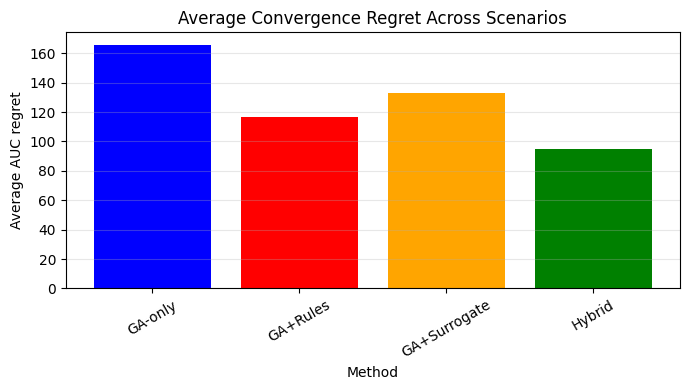

Saved: figures/ablation_average_regret.pdf


In [8]:
#CELL 8 - Plot average regret
plt.figure(figsize=(7,4))
plt.bar(
    methods,
    plot_df["AUCregret_mean"],
    color=[colors[m] for m in methods]
)

plt.ylabel("Average AUC regret")
plt.xlabel("Method")
plt.title("Average Convergence Regret Across Scenarios")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_average_regret.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

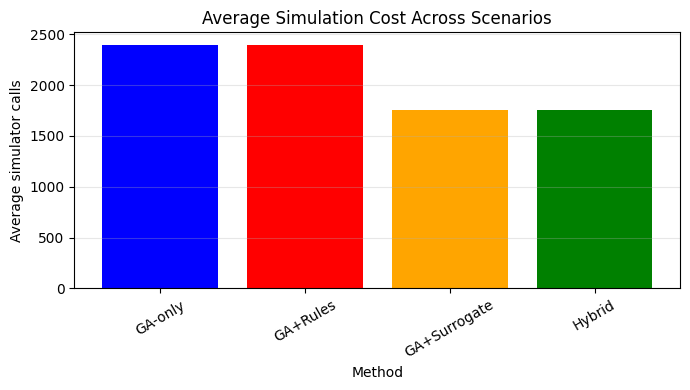

Saved: figures/ablation_average_simcalls.pdf


In [9]:
#CELL 9 - Plot simulation cost
plt.figure(figsize=(7,4))
plt.bar(
    methods,
    plot_df["SimCalls_mean"],
    color=[colors[m] for m in methods]
)

plt.ylabel("Average simulator calls")
plt.xlabel("Method")
plt.title("Average Simulation Cost Across Scenarios")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_average_simcalls.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [10]:
#CELL 10 - Scenario-wise delta fitness vs GA-only
wide_fitness = df.pivot(index="Scenario", columns="MethodLabel", values="Fitness")

for method in ["GA+Rules", "GA+Surrogate", "Hybrid"]:
    wide_fitness[f"Delta_{method}_vs_GA"] = (
        wide_fitness[method] - wide_fitness["GA-only"]
    )

wide_fitness

MethodLabel,GA-only,GA+Rules,GA+Surrogate,Hybrid,Delta_GA+Rules_vs_GA,Delta_GA+Surrogate_vs_GA,Delta_Hybrid_vs_GA
Scenario,,,,,,,
S1_normal,99.374014,99.178881,99.404899,99.222139,-0.195133,0.030884,-0.151875
S2_ramadan,98.904381,98.987936,98.939039,99.004678,0.083554,0.034658,0.100297
S3_stress_highcarb,98.221204,98.714782,97.658713,98.278060,0.493578,-0.562492,0.056856
S4_exercise_lowcarb,97.603081,97.670586,97.656148,95.864115,0.067505,0.053067,-1.738966


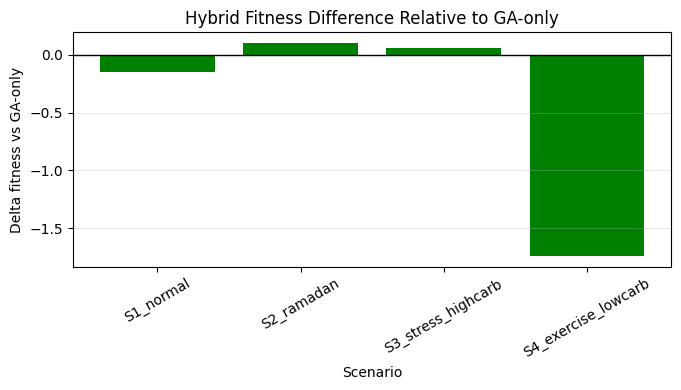

Saved: figures/ablation_delta_hybrid_vs_ga.pdf


In [11]:
#CELL 11 - Plot Hybrid delta fitness vs GA-only
delta = wide_fitness["Delta_Hybrid_vs_GA"].reset_index()
delta.columns = ["Scenario", "DeltaFitness"]

plt.figure(figsize=(7,4))
plt.bar(delta["Scenario"], delta["DeltaFitness"], color=colors["Hybrid"])
plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Delta fitness vs GA-only")
plt.xlabel("Scenario")
plt.title("Hybrid Fitness Difference Relative to GA-only")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_delta_hybrid_vs_ga.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [12]:
#CELL 12 - Scenario-wise delta regret vs GA-only
wide_regret = df.pivot(index="Scenario", columns="MethodLabel", values="AUCregret")

for method in ["GA+Rules", "GA+Surrogate", "Hybrid"]:
    wide_regret[f"Delta_{method}_vs_GA"] = (
        wide_regret[method] - wide_regret["GA-only"]
    )

wide_regret

MethodLabel,GA-only,GA+Rules,GA+Surrogate,Hybrid,Delta_GA+Rules_vs_GA,Delta_GA+Surrogate_vs_GA,Delta_Hybrid_vs_GA
Scenario,,,,,,,
S1_normal,9.581747,15.793334,12.287739,12.025708,6.211588,2.705992,2.443961
S2_ramadan,13.568054,6.569429,3.938312,15.645896,-6.998626,-9.629743,2.077842
S3_stress_highcarb,201.736015,413.388107,261.821950,88.379785,211.652092,60.085935,-113.356230
S4_exercise_lowcarb,438.783601,30.532036,253.205443,263.188304,-408.251565,-185.578157,-175.595296


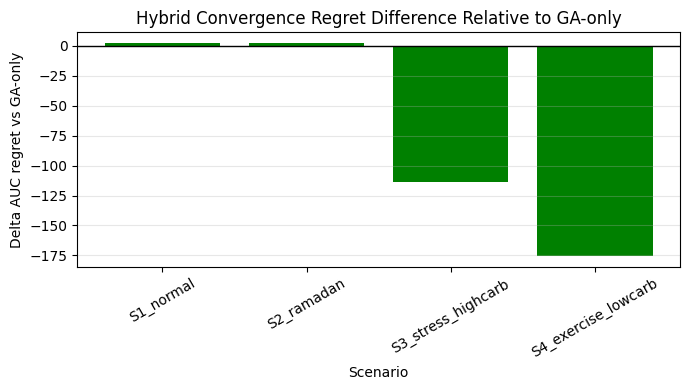

Saved: figures/ablation_delta_regret_hybrid_vs_ga.pdf


In [13]:
#CELL 13 - Plot Hybrid delta regret vs GA-only
delta_regret = wide_regret["Delta_Hybrid_vs_GA"].reset_index()
delta_regret.columns = ["Scenario", "DeltaRegret"]

plt.figure(figsize=(7,4))
plt.bar(delta_regret["Scenario"], delta_regret["DeltaRegret"], color=colors["Hybrid"])
plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Delta AUC regret vs GA-only")
plt.xlabel("Scenario")
plt.title("Hybrid Convergence Regret Difference Relative to GA-only")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/ablation_delta_regret_hybrid_vs_ga.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [14]:
#CELL 14 - Literature comparison table
literature_rows = [
    {
        "Study": "Simulation-driven insulin therapy optimization",
        "Approach": "Simulation-based optimization of insulin therapy profiles",
        "Relation_to_ours": "Similar simulation-driven framing; our work adds explicit surrogate-assisted GA and safety rules.",
        "Direct_comparison": "No, different simulator/protocol."
    },
    {
        "Study": "Surrogate models for clinical decision support in T1DM",
        "Approach": "Surrogate modeling to accelerate complex simulation or decision-support models",
        "Relation_to_ours": "Supports the motivation for surrogate acceleration; our work evaluates surrogate bias inside GA optimization.",
        "Direct_comparison": "No, different task and model."
    },
    {
        "Study": "Model-based insulin dose optimization",
        "Approach": "Iterative model-based insulin dose adjustment",
        "Relation_to_ours": "Shares optimization objective; our method focuses on GA/surrogate/rule ablation under daily-life scenarios.",
        "Direct_comparison": "No, different algorithm and assumptions."
    },
    {
        "Study": "AI/DSS for type 1 diabetes",
        "Approach": "AI-assisted decision support for insulin dosing",
        "Relation_to_ours": "Provides broader context for AI-based insulin decision support; our work studies offline simulation-based optimization.",
        "Direct_comparison": "No, clinical endpoints differ."
    },
]

lit_df = pd.DataFrame(literature_rows)
lit_df

,Study,Approach,Relation_to_ours,Direct_comparison
0,Simulation-driven insulin therapy optimization,Simulation-based optimization of insulin thera...,Similar simulation-driven framing; our work ad...,"No, different simulator/protocol."
1,Surrogate models for clinical decision support...,Surrogate modeling to accelerate complex simul...,Supports the motivation for surrogate accelera...,"No, different task and model."
2,Model-based insulin dose optimization,Iterative model-based insulin dose adjustment,Shares optimization objective; our method focu...,"No, different algorithm and assumptions."
3,AI/DSS for type 1 diabetes,AI-assisted decision support for insulin dosing,Provides broader context for AI-based insulin ...,"No, clinical endpoints differ."


In [15]:
#CELL 15 - Literature comparison LaTeX table
latex_lit = lit_df.to_latex(
    index=False,
    escape=True,
    caption="Qualitative comparison with related literature.",
    label="tab:literature_comparison"
)

print(latex_lit)

\begin{table}
\caption{Qualitative comparison with related literature.}
\label{tab:literature_comparison}
\begin{tabular}{llll}
\toprule
Study & Approach & Relation\_to\_ours & Direct\_comparison \\
\midrule
Simulation-driven insulin therapy optimization & Simulation-based optimization of insulin therapy profiles & Similar simulation-driven framing; our work adds explicit surrogate-assisted GA and safety rules. & No, different simulator/protocol. \\
Surrogate models for clinical decision support in T1DM & Surrogate modeling to accelerate complex simulation or decision-support models & Supports the motivation for surrogate acceleration; our work evaluates surrogate bias inside GA optimization. & No, different task and model. \\
Model-based insulin dose optimization & Iterative model-based insulin dose adjustment & Shares optimization objective; our method focuses on GA/surrogate/rule ablation under daily-life scenarios. & No, different algorithm and assumptions. \\
AI/DSS for type 1 dia

In [16]:
#CELL 16 - Ablation summary table for paper
paper_ablation = avg_perf[[
    "MethodLabel",
    "Fitness_mean",
    "TIR_mean",
    "TAR_mean",
    "AUCregret_mean",
    "SimCalls_mean",
    "Reduction_vs_GA_percent"
]].copy()

paper_ablation = paper_ablation.sort_values("MethodLabel")

paper_ablation

,MethodLabel,Fitness_mean,TIR_mean,TAR_mean,AUCregret_mean,SimCalls_mean,Reduction_vs_GA_percent
0,GA-only,98.525670,100.000000,0.000000,165.917354,2400.0,0.0
1,GA+Rules,98.638046,100.000000,0.000000,116.570726,2400.0,0.0
2,GA+Surrogate,98.414700,100.000000,0.000000,132.813361,1752.0,27.0
3,Hybrid,98.092248,99.913495,0.086505,94.809923,1752.0,27.0
